# RMP2 QChem test: He cc-pv5z, $\theta=0.01$
In this notebook we will analythe the results compared with qchem for He cc-pv5z basis set with RMP2 method and $\theta=0.01$. In particular we will check the implementation using `eig` since the use of `eigh` is not possible for complex matrices.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto
from py_mods.src.SCF.CSRHF import RHF_theta_traj, CS_RHF_ContextClass, CS_RHF 
from Dev.CSMP2_dev import CS_MP2
from py_mods.src.SCF.external import RHF_context_from_pyscf

We start by setting up the atom with the cc-pV5Z basis set:

In [ ]:
large_basis = """
He    S
      5.285000E+02           0.000000E+00           9.400000E-04           0.000000E+00           0.000000E+00
      7.931000E+01           0.000000E+00           7.214000E-03           0.000000E+00           0.000000E+00
      1.805000E+01           0.000000E+00           3.597500E-02           0.000000E+00           0.000000E+00
      5.085000E+00           0.000000E+00           1.277820E-01           0.000000E+00           0.000000E+00
      1.609000E+00           1.000000E+00           3.084700E-01           0.000000E+00           0.000000E+00
      5.363000E-01           0.000000E+00           4.530520E-01           1.000000E+00           0.000000E+00
      1.833000E-01           0.000000E+00           2.388840E-01           0.000000E+00           1.000000E+00
He    S
      0.0481900              1.0000000
He    P
      5.994000E+00           1.000000E+00           0.000000E+00           0.000000E+00
      1.745000E+00           0.000000E+00           1.000000E+00           0.000000E+00
      5.600000E-01           0.000000E+00           0.000000E+00           1.000000E+00
He    P
      0.1626000              1.0000000
He    D
      4.299000E+00           1.000000E+00           0.000000E+00
      1.223000E+00           0.000000E+00           1.000000E+00
He    D
      0.3510000              1.0000000
He    F
      2.680000E+00           1.0000000
He    F
      0.6906000              1.0000000
END
"""

mol_He_qz = gto.M(
    atom="He 0 0 0",
    spin=0,
    charge=0,
    basis='sto-3g'
)

mol_He_qz.basis = {"He": gto.basis.parse(large_basis)}
mol_He_qz.build()

T_qz_He = mol_He_qz.intor("int1e_kin")
V_qz_He = mol_He_qz.intor("int1e_nuc")
S_qz_He = mol_He_qz.intor("int1e_ovlp")
eri_qz_He = mol_He_qz.intor("int2e")

We define this function which will be useful later:

In [ ]:
def round_significant_figures(arr, sig_figs=4):
    """
    Rounds array to significant figures.
    """
    to_round = (arr != 0)

    logs = np.floor(np.log10(np.abs(arr[to_round])))
    decimals = sig_figs - 1 - logs

    rounded = np.zeros_like(arr, dtype=np.float64)
    
    # Apply the scaling factor
    power = 10.0 ** decimals
    
    # Round elements
    rounded_values = np.round(arr[to_round] * power) / power
    rounded[to_round] = rounded_values
    
    return rounded

The reference value of Qchem for the CSRHF with $\theta=0.01$ is $-2.8615224532 + 0.0000035001i$. The implementation SCF result is calculated as:

In [ ]:
CSRHF_reference_energy = -2.8615224532 + 0.0000035001j
He_qz_001 = CS_RHF_ContextClass(
    S_qz_He,
    T_qz_He,
    V_qz_He,
    eri_qz_He,
    2,
    max_iter=1000,
    theta=0.01,
    verbose=True,
    threshold=5E-15
)

He_qz_001_res = CS_RHF(He_qz_001)
print('\n\n\n\n')
print(f'CSRHF energy: {He_qz_001_res.E_RHF}')
print(f'Difference with reference: {He_qz_001_res.E_RHF - CSRHF_reference_energy}')

Converging unscaled case:
--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
--------------------------------------------------------------------------------------------------------------------------------
    0            0.0000000000000000+0.0000000000000000j            0.0000000000000000+0.0000000000000000j     0.0000E+00     0.0000E+00j
    1           -2.7501626378449946+0.0000000000000000j           -2.7501626378449946+0.0000000000000000j     4.6679E-01     0.0000E+00j
    2           -2.8601426210555583+0.0000000000000000j           -0.1099799832105637+0.0000000000000000j     5.5605E-02     0.0000E+00j
    3           -2.8614877338059284+0.0000000000000000j           -0.0013451127503701+0.0000000000000000j     6.9937E-03     0.0000E+00j
    4           -2.8615207093309940+0

The CS-RMP2 reference value for this case is $-2.89724685 + 0.00002186i$. Comparing with the implementation:

In [ ]:
RMP2_reference_energy = (-2.89724685 + 0.00002186j)

He_qz_001_MP2 = CS_MP2(He_qz_001_res)
print(f'CS-RMP2 energy: {He_qz_001_MP2.E_MP2}')
print(f'Difference with reference: {He_qz_001_MP2.E_MP2 - RMP2_reference_energy:.4e}')

CS-RMP2 energy: (-2.8972400695134493-0.0006925792411673008j)
Difference with reference: 6.7805e-06-7.1444e-04j


And with the rounded orbital energies (since we only have 4 significant figures from qchem):

In [ ]:
orig_eorb = np.copy(He_qz_001_res.e_orb)
eorb_round_real = round_significant_figures(He_qz_001_res.e_orb.real, sig_figs=4)
eorb_round_imag = round_significant_figures(He_qz_001_res.e_orb.imag, sig_figs=4)

eorb_round = eorb_round_real + 1j * eorb_round_imag

He_qz_001_res.e_orb = eorb_round

He_qz_001_MP2_round= CS_MP2(He_qz_001_res)
print(f'CS-RMP2 energy: {He_qz_001_MP2.E_MP2}')
print(f'Difference with reference: {He_qz_001_MP2.E_MP2 - RMP2_reference_energy:.4e}')

He_qz_001_res.e_orb = orig_eorb

CS-RMP2 energy: (-2.8972400695134493-0.0006925792411673008j)
Difference with reference: 6.7805e-06-7.1444e-04j


Which shows a non-negligible error in the MP2 energy. 

## Locating the cause
The first idea is the same as always: Virtuals are not well defined, inducing error. Since we are limited at this moment by the results of Qchem, we can see what we can compare: orbital energies. 

In [ ]:
qchem_eorb_str = '''
    (-9.179e-01,+5.680e-06)
    (+9.872e-02,-2.423e-03)
    (+3.478e-01,-6.475e-03)
    (+3.478e-01,-6.475e-03)
    (+3.478e-01,-6.475e-03)
    (+6.852e-01,-1.694e-02)
    (+1.149e+00,-2.242e-02)
    (+1.149e+00,-2.242e-02)
    (+1.149e+00,-2.242e-02)
    (+1.149e+00,-2.242e-02)
    (+1.149e+00,-2.242e-02)
    (+1.476e+00,-2.860e-02)
    (+1.476e+00,-2.860e-02)
    (+1.476e+00,-2.860e-02)
    (+2.955e+00,-6.808e-02)
    (+3.003e+00,-5.914e-02)
    (+3.003e+00,-5.914e-02)
    (+3.003e+00,-5.914e-02)
    (+3.003e+00,-5.914e-02)
    (+3.003e+00,-5.914e-02)
    (+3.003e+00,-5.914e-02)
    (+3.003e+00,-5.914e-02)
    (+4.576e+00,-8.963e-02)
    (+4.576e+00,-8.963e-02)
    (+4.576e+00,-8.963e-02)
    (+4.576e+00,-8.963e-02)
    (+4.576e+00,-8.963e-02)
    (+5.129e+00,-1.028e-01)
    (+5.129e+00,-1.028e-01)
    (+5.129e+00,-1.028e-01)
    (+1.253e+01,-2.480e-01)
    (+1.253e+01,-2.480e-01)
    (+1.253e+01,-2.480e-01)
    (+1.253e+01,-2.480e-01)
    (+1.253e+01,-2.480e-01)
    (+1.253e+01,-2.480e-01)
    (+1.253e+01,-2.480e-01)
    (+1.362e+01,-3.208e-01)
    (+1.664e+01,-3.331e-01)
    (+1.664e+01,-3.331e-01)
    (+1.664e+01,-3.331e-01)
    (+1.664e+01,-3.331e-01)
    (+1.664e+01,-3.331e-01)
    (+1.809e+01,-3.723e-01)
    (+1.809e+01,-3.723e-01)
    (+1.809e+01,-3.723e-01)
'''

qchem_eorb_list = qchem_eorb_str.split('\n')[1:-1]
qchem_eorb_list = [e.strip().replace('(', '').replace(')', '') for e in qchem_eorb_list]

qchem_eorb_re = [float(a.split(',')[0] )for a in qchem_eorb_list]
qchem_eorb_im = [float(a.split(',')[1] )for a in qchem_eorb_list]

qchem_eorb_arr = np.array(qchem_eorb_re) + 1j * np.array(qchem_eorb_im)

In [ ]:
print(He_qz_001_res.e_orb )

[-0.91793256+5.68034661e-06j  0.09871581-2.42252464e-03j
  0.34776625-6.47500020e-03j  0.34776625-6.47500020e-03j
  0.34776625-6.47500020e-03j  0.68519451-1.69382481e-02j
  1.14874718-2.24162064e-02j  1.14874718-2.24162064e-02j
  1.14874718-2.24162064e-02j  1.14874718-2.24162064e-02j
  1.14874718-2.24162064e-02j  1.47579723-2.86019422e-02j
  1.47579723-2.86019422e-02j  1.47579723-2.86019422e-02j
  2.95497077-6.80835921e-02j  3.00262996-5.91382119e-02j
  3.00262996-5.91382119e-02j  3.00262996-5.91382119e-02j
  3.00262996-5.91382119e-02j  3.00262996-5.91382119e-02j
  3.00262996-5.91382119e-02j  3.00262996-5.91382119e-02j
  4.57642802-8.96266202e-02j  4.57642802-8.96266202e-02j
  4.57642802-8.96266202e-02j  4.57642802-8.96266202e-02j
  4.57642802-8.96266202e-02j  5.1292926 -1.02849212e-01j
  5.1292926 -1.02849212e-01j  5.1292926 -1.02849212e-01j
 12.53328377-2.48042813e-01j 12.53328377-2.48042813e-01j
 12.53328377-2.48042813e-01j 12.53328377-2.48042813e-01j
 12.53328377-2.48042813e-01j 12

Comparing the difference from implementation and qchem energies:

In [ ]:
diff = He_qz_001_res.e_orb - qchem_eorb_arr

eorb_round_real = round_significant_figures(He_qz_001_res.e_orb.real, sig_figs=4)
eorb_round_imag = round_significant_figures(He_qz_001_res.e_orb.imag, sig_figs=4)

eorb_round = eorb_round_real + 1j * eorb_round_imag

diff_round = eorb_round - qchem_eorb_arr

print(diff)
print(diff_round)

[-3.25644531e-05+3.46606895e-10j -4.18574305e-06+4.75357311e-07j
 -3.37476657e-05-2.02850450e-10j -3.37476657e-05-2.02849852e-10j
 -3.37476657e-05-2.02850155e-10j -5.49016296e-06+1.75187087e-06j
 -2.52819228e-04+3.79360491e-06j -2.52819228e-04+3.79360491e-06j
 -2.52819228e-04+3.79360491e-06j -2.52819228e-04+3.79360491e-06j
 -2.52819228e-04+3.79360491e-06j -2.02772047e-04-1.94215634e-06j
 -2.02772047e-04-1.94215634e-06j -2.02772047e-04-1.94215634e-06j
 -2.92318932e-05-3.59208512e-06j -3.70036997e-04+1.78813324e-06j
 -3.70036997e-04+1.78813324e-06j -3.70036997e-04+1.78813324e-06j
 -3.70036997e-04+1.78813324e-06j -3.70036997e-04+1.78813324e-06j
 -3.70036997e-04+1.78813324e-06j -3.70036997e-04+1.78813324e-06j
  4.28019048e-04+3.37984400e-06j  4.28019048e-04+3.37984400e-06j
  4.28019048e-04+3.37984400e-06j  4.28019048e-04+3.37984400e-06j
  4.28019048e-04+3.37984400e-06j  2.92595273e-04-4.92121388e-05j
  2.92595273e-04-4.92121388e-05j  2.92595273e-04-4.92121388e-05j
  3.28376677e-03-4.281260

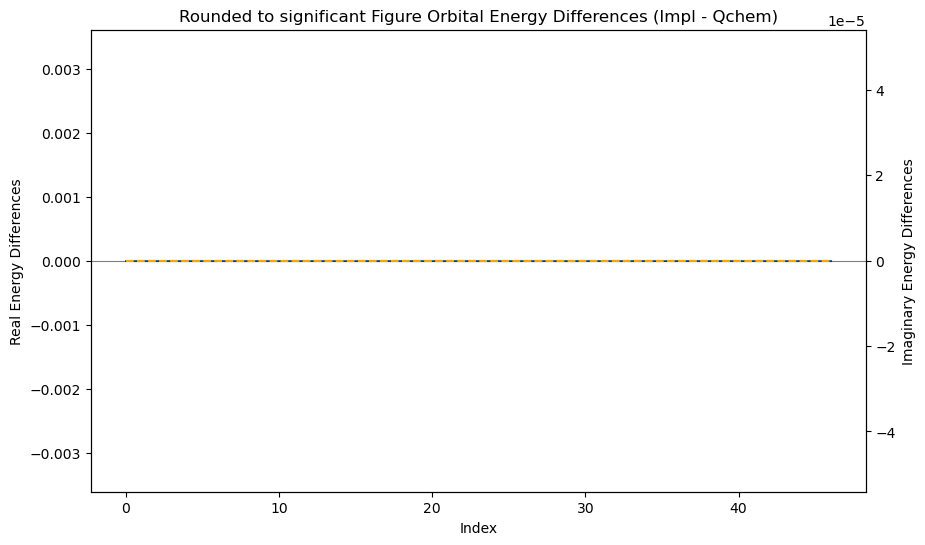

In [ ]:
x_range = np.linspace(0, len(diff), len(diff))

fig, ax1 = plt.subplots(figsize=(10, 6))

# real
ax1.set_xlabel('Index')
ax1.set_ylabel('Real Energy Differences')
ax1.plot(x_range, diff_round.real, label='Real')
ax1.tick_params(axis='y')

# imag
ax2 = ax1.twinx()
ax2.set_ylabel('Imaginary Energy Differences')
ax2.plot(x_range, diff_round.imag, linestyle='--', label='Imag', c='orange')
ax2.tick_params(axis='y')

#scale
max_real = np.max(np.abs(diff.real))
max_imag = np.max(np.abs(diff.imag))
limit_real = max_real * 1.1
limit_imag = max_imag * 1.1

ax1.set_ylim(-limit_real, limit_real)
ax2.set_ylim(-limit_imag, limit_imag)

ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)

plt.title("Rounded to significant Figure Orbital Energy Differences (Impl - Qchem)")
plt.show()

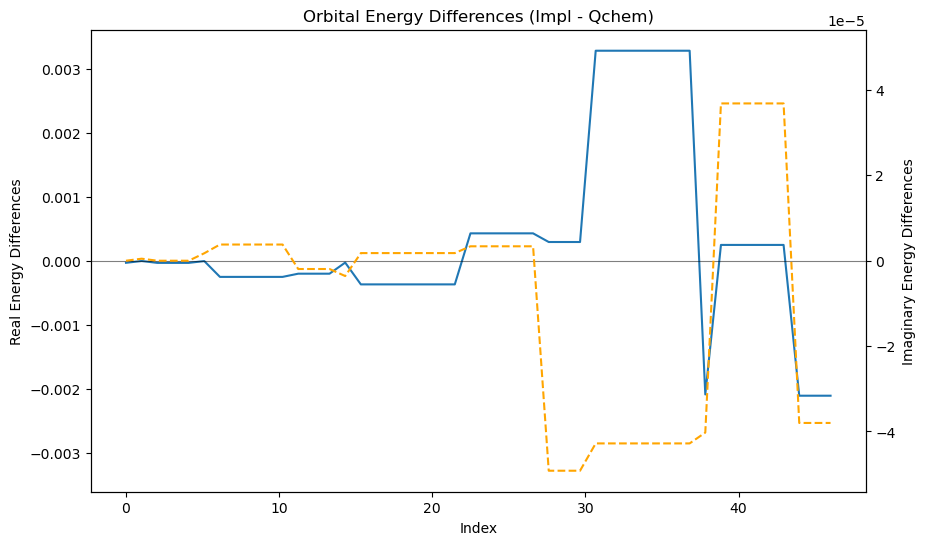

In [ ]:
x_range = np.linspace(0, len(diff), len(diff))

fig, ax1 = plt.subplots(figsize=(10, 6))

# real
ax1.set_xlabel('Index')
ax1.set_ylabel('Real Energy Differences')
ax1.plot(x_range, diff.real, label='Real')
ax1.tick_params(axis='y')

# imag
ax2 = ax1.twinx()
ax2.set_ylabel('Imaginary Energy Differences')
ax2.plot(x_range, diff.imag, linestyle='--', label='Imag', c='orange')
ax2.tick_params(axis='y')

#scale
max_real = np.max(np.abs(diff.real))
max_imag = np.max(np.abs(diff.imag))
limit_real = max_real * 1.1
limit_imag = max_imag * 1.1

ax1.set_ylim(-limit_real, limit_real)
ax2.set_ylim(-limit_imag, limit_imag)

ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)

plt.title("Orbital Energy Differences (Impl - Qchem)")
plt.show()